Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.9 MB/s eta 0:00:00
✅ Libraries loaded
   CatBoost version : 1.2.10
✅ Config loaded
   Datasets              : 11
   Train/Test            : 70% / 30%
   iterations            : 100
   depth                 : 6
   learning_rate         : auto
   class_weights         : [1.0, 1.5]
   early_stopping_rounds : 20
   task_type             : CPU
  CatBoost — depth Sensitivity Analysis

  AAC        → d=3:0.798  d=4:0.809  d=5:0.810  d=6:0.812  d=7:0.809  d=8:0.819
             Best depth = 8  (AUC=0.8194)

  DPC        → d=3:0.740  d=4:0.754  d=5:0.744  d=6:0.764  d=7:0.774  d=8:0.761
             Best depth = 7  (AUC=0.7744)

  CTDC       → d=3:0.805  d=4:0.810  d=5:0.820  d=6:0.817  d=7:0.818  d=8:0.812
             Best depth = 5  (AUC=0.8204)

  CTDT       → d=3:0.793  d=4:0.795  d=5:0.805  d=6:0.808  d=7:0.813  d=8:0.804
             Best depth = 7  (AUC=0.8128)

  GAAC       → d=3:0.805  d=4:0.811  d=5:

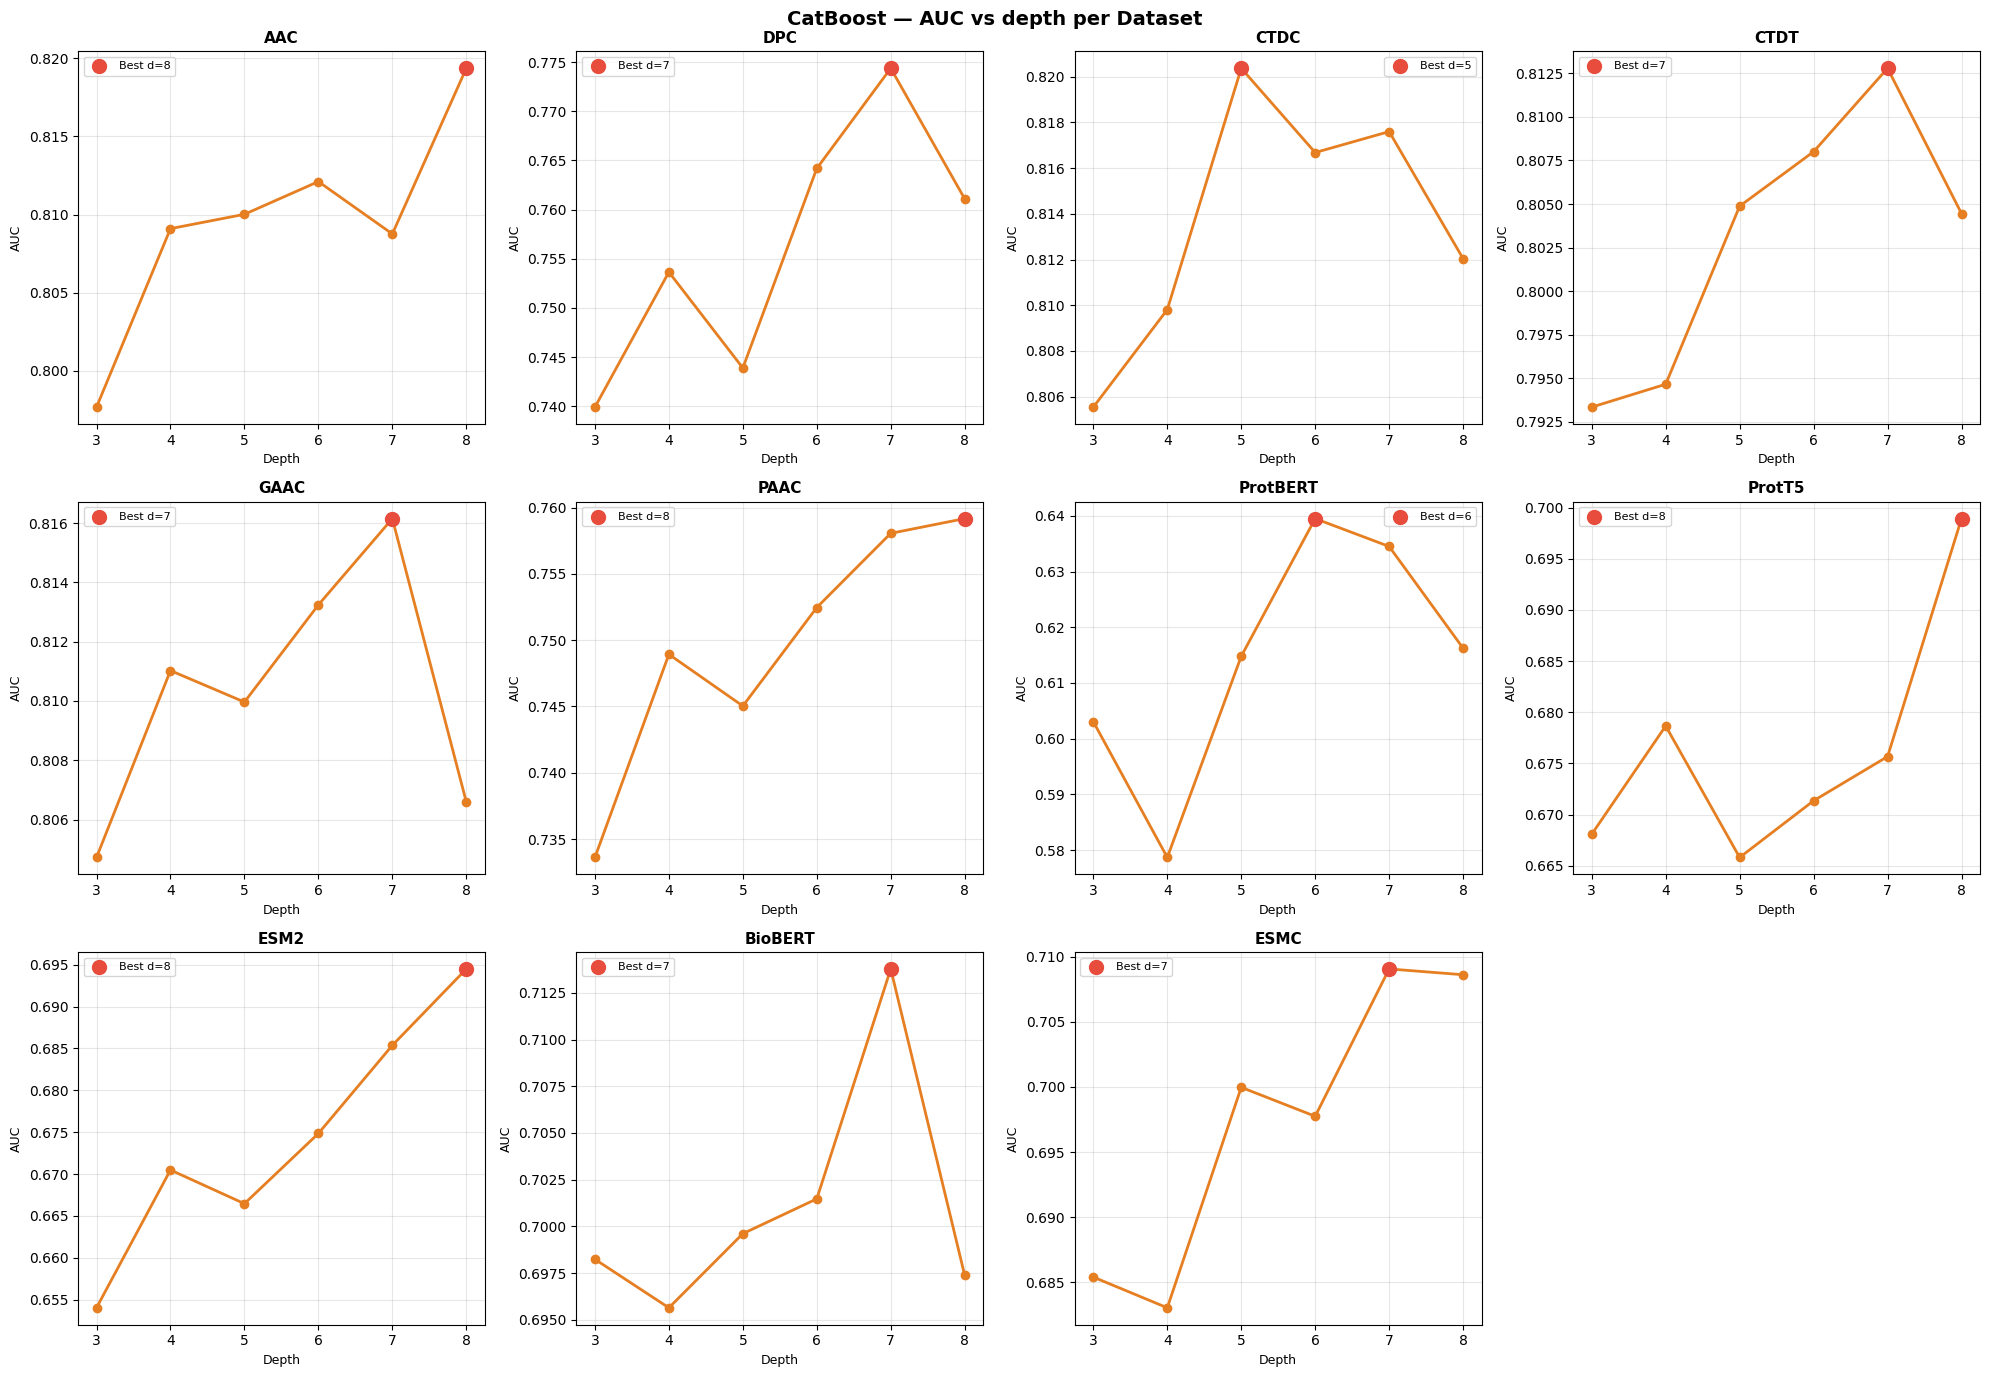

✅ Depth sensitivity plot saved
  CatBoost — Training & Evaluation on 11 Datasets

────────────────────────────────────────────────────────────
  Dataset : AAC  (AAC_features.csv)
  Shape   : (2190, 21)  |  Features: 20  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  Depth   : 8

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7793
  Sensitivity : 0.7110
  Specificity : 0.8249
  F1 Score    : 0.7206
  MCC         : 0.5384
  AUC         : 0.8194
  Best iter   : 98
  TP=187  TN=325  FP=69  FN=76
  Probabilities saved → /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/catboost/AAC_CB_probabilities.csv

────────────────────────────────────────────────────────────
  Dataset : DPC  (DPC_features.csv)
  Shape   : (2190, 401)  |  Features: 400  |  Pos: 876  Neg: 1314
  Train   : 1533 samples  |  Test: 657 samples
  Depth   : 7

  ── Results ──────────────────────────────────────
  Accuracy    : 0.7002
  Sensitivity : 0.7338
  Specifici

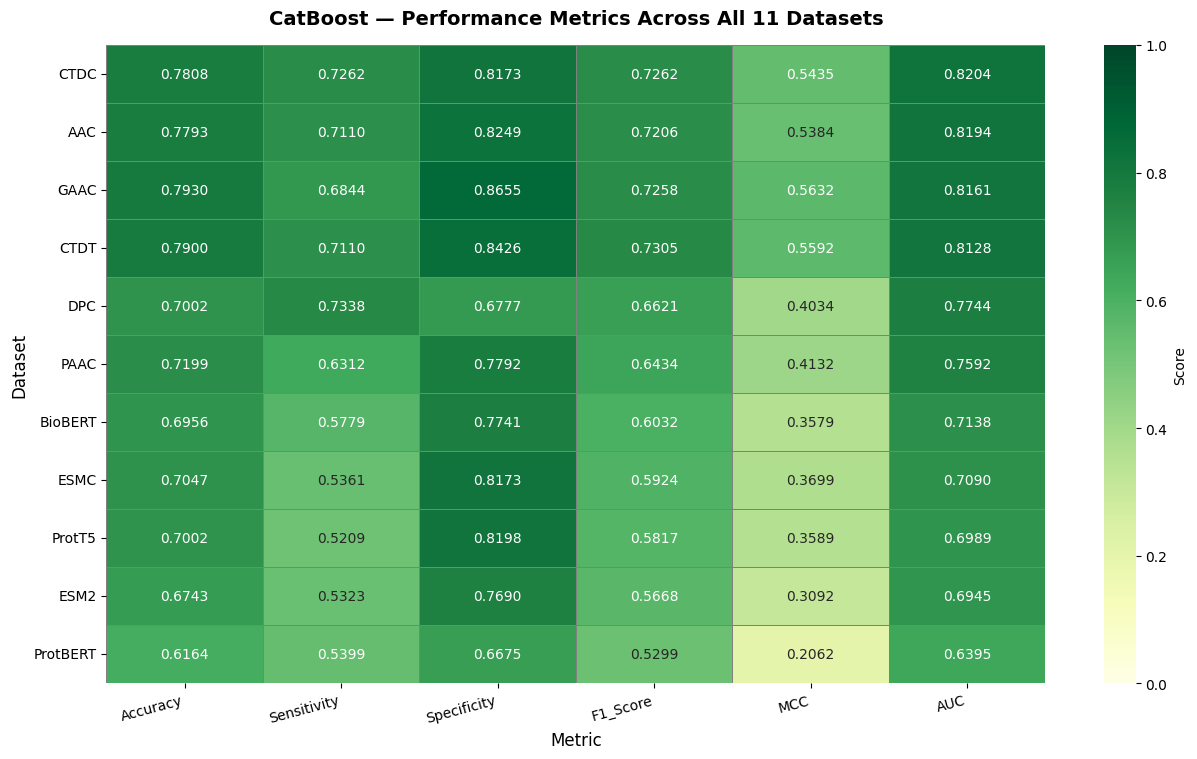

✅ Metrics heatmap saved


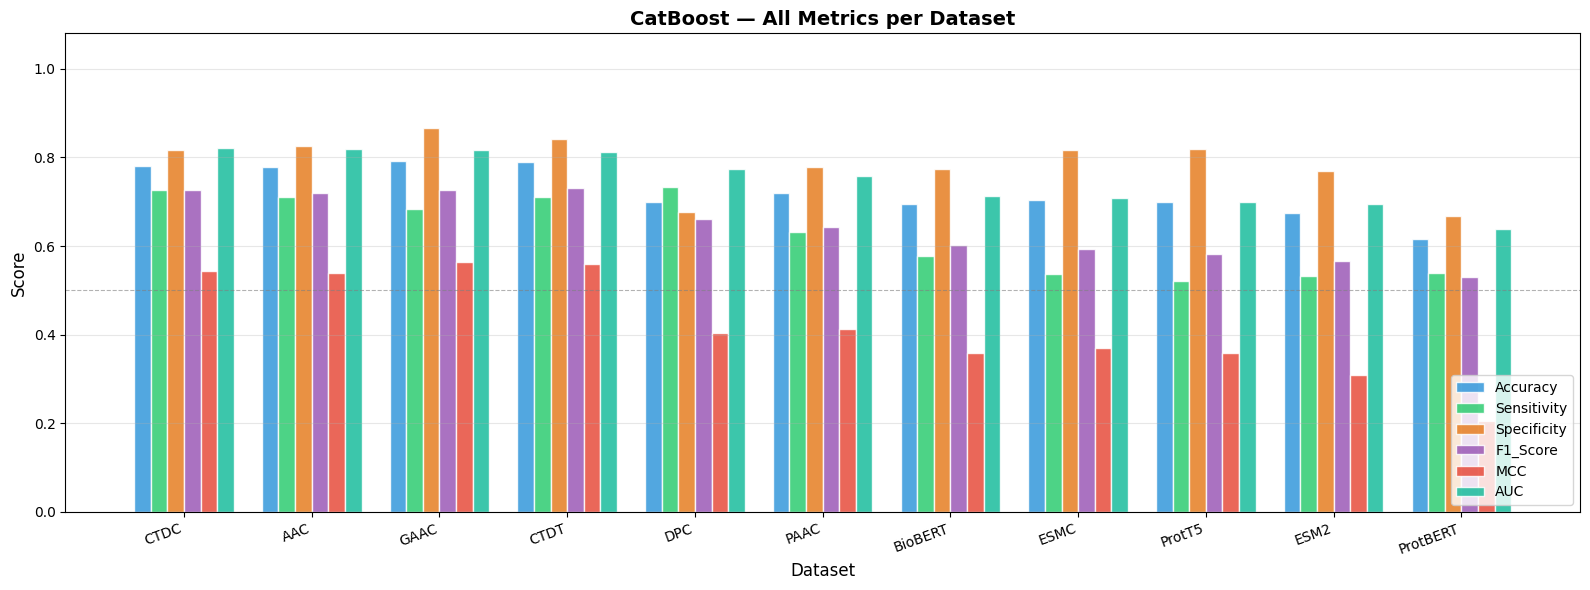

✅ Grouped bar chart saved


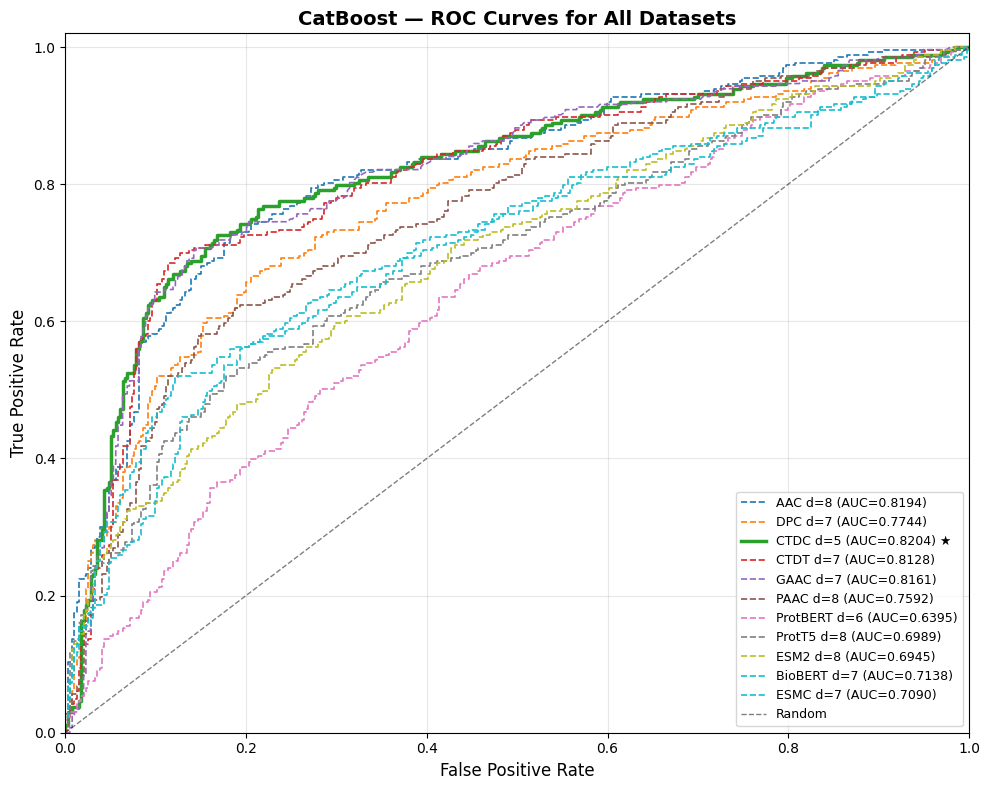

✅ ROC curves saved


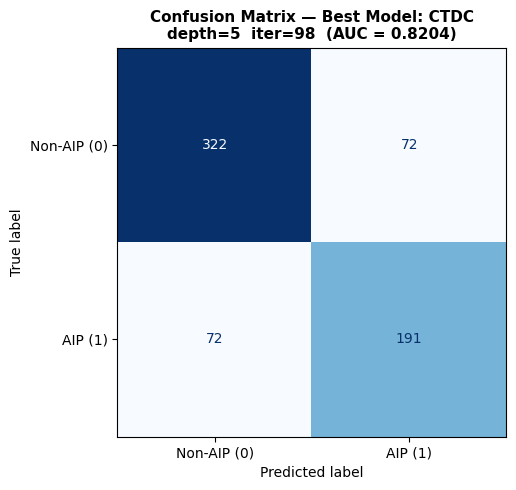

✅ Confusion matrix saved (CTDC)


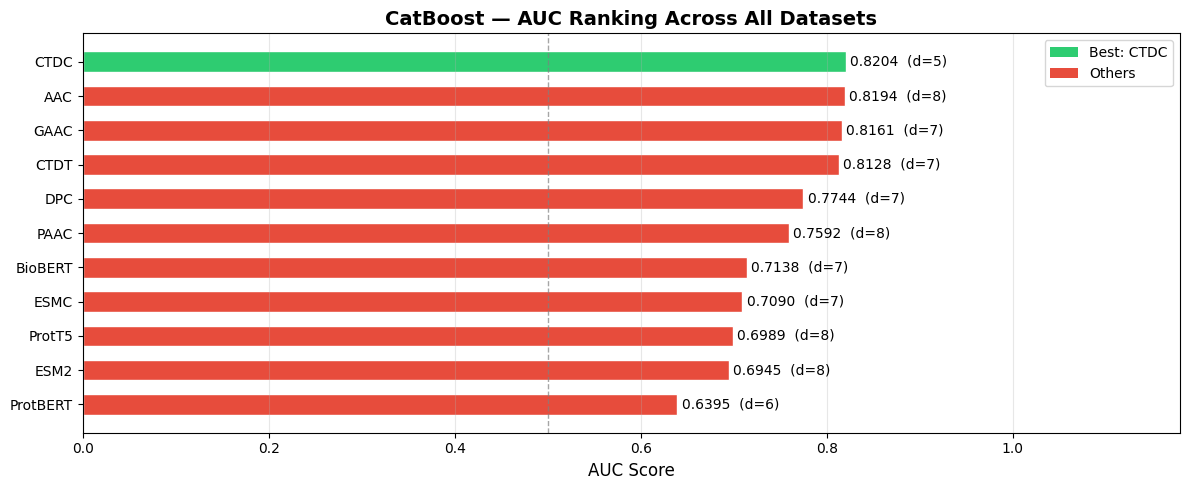

✅ AUC ranking chart saved


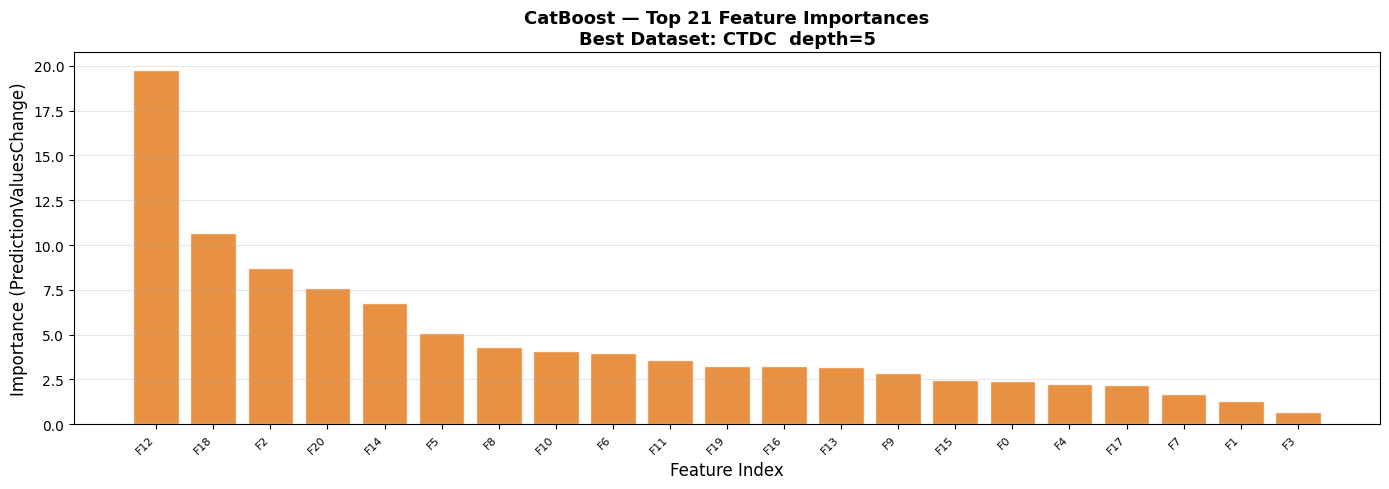

✅ Feature importance plot saved (CTDC)


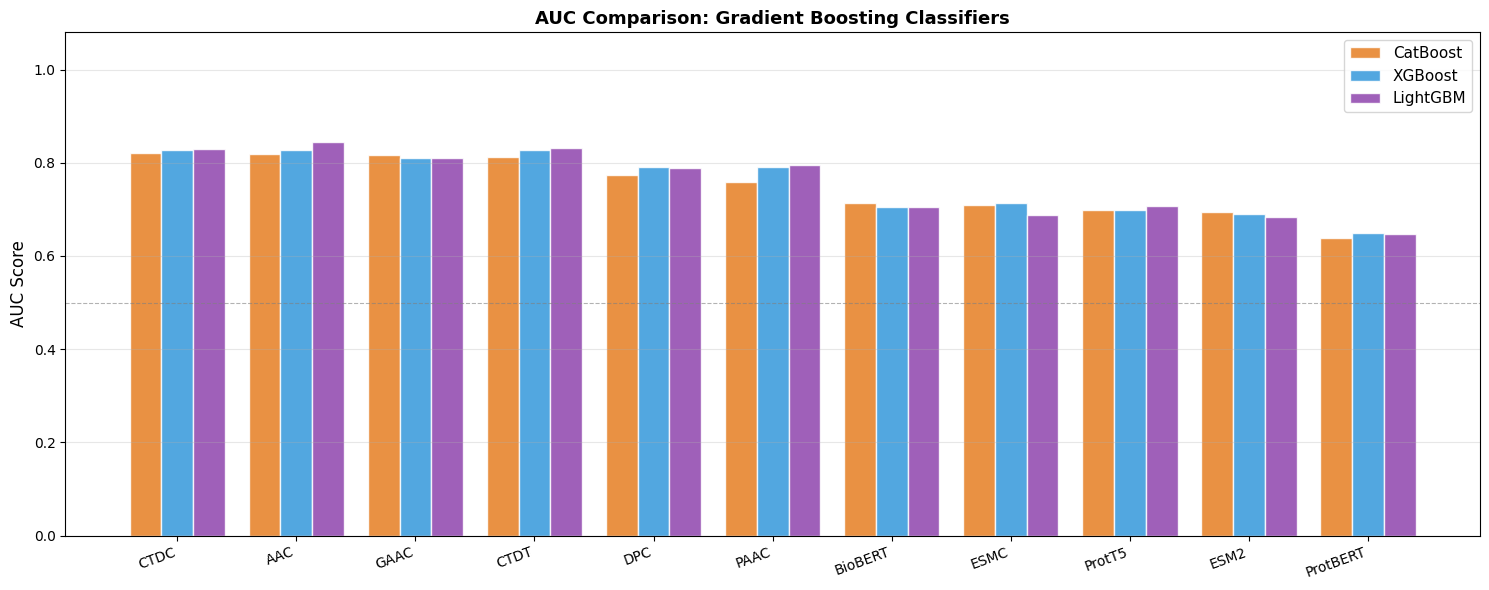

✅ Gradient boosters comparison plot saved (CatBoost, XGBoost, LightGBM)
  CATBOOST — FINAL SUMMARY

  Results saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/catboost
  Figures saved to  : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/catboost
  Model saved to    : /content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/catboost

─────────────────────────────────────────────────────────────────
  Dataset         d  iter      Acc       Sn       Sp       F1      MCC      AUC
─────────────────────────────────────────────────────────────────
  CTDC            5    98   0.7808   0.7262   0.8173   0.7262   0.5435   0.8204 ★
  AAC             8    98   0.7793   0.7110   0.8249   0.7206   0.5384   0.8194
  GAAC            7    34   0.7930   0.6844   0.8655   0.7258   0.5632   0.8161
  CTDT            7    93   0.7900   0.7110   0.8426   0.7305   0.5592   0.8128
  DPC             7    95   0.7002   0.7338   0.6777   0.6621   0.4034   0.7744

In [1]:
# ============================================================
#   CELL 1 — Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
#   CELL 2 — Install & Import Libraries
# ============================================================
!pip install catboost -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

import catboost
print("✅ Libraries loaded")
print(f"   CatBoost version : {catboost.__version__}")


# ============================================================
#   CELL 3 — Configuration
# ============================================================

FEATURE_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/data/features"
RESULTS_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/catboost"
FIGURES_DIR  = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results/figures/catboost"
MODELS_DIR   = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/models/catboost"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

# ── All 11 feature datasets ──────────────────────────────────
DATASETS = {
    "AAC"     : "AAC_features.csv",
    "DPC"     : "DPC_features.csv",
    "CTDC"    : "CTDC_features.csv",
    "CTDT"    : "CTDT_features.csv",
    "GAAC"    : "GAAC_features.csv",
    "PAAC"    : "PAAC_features.csv",
    "ProtBERT": "ProtBERT_features.csv",
    "ProtT5"  : "ProtT5_features.csv",
    "ESM2"    : "ESM2_features.csv",
    "BioBERT" : "BioBERT_features.csv",
    "ESMC"    : "ESMC_features.csv",
}

# ── CatBoost hyperparameters ─────────────────────────────────
#
#  CatBoost vs XGBoost vs LightGBM:
#
#  XGBoost    — level-wise tree growth, good general performance
#  LightGBM   — leaf-wise growth, fastest on large datasets
#  CatBoost   — Ordered Boosting, best on small/medium datasets
#               with categorical features; robust to overfitting
#               without extensive tuning
#
#  Key parameters:
#    iterations       : number of boosting rounds (= n_estimators)
#    depth            : max tree depth (2–10; default 6)
#                       CatBoost is sensitive to depth —
#                       deeper trees overfit quickly
#    learning_rate    : step size per round
#                       if None, CatBoost auto-selects based on
#                       dataset size ✅ recommended
#    l2_leaf_reg      : L2 regularisation on leaf values (default 3)
#    border_count     : number of splits for numerical features
#                       (default 254; lower = faster)
#    class_weights    : list [neg_weight, pos_weight] for imbalance
#                       set to [1.0, neg/pos ratio]
#    early_stopping_rounds : stop if no improvement for N rounds
#    eval_metric      : metric to monitor during training
#    verbose          : 0 = silent
#    task_type        : "GPU" if T4 GPU available, else "CPU"
#    random_seed      : reproducibility
#
CB_PARAMS = {
    "iterations"           : 100,
    "depth"                : 6,
    "learning_rate"        : None,     # None = CatBoost auto-selects ✅
    "l2_leaf_reg"          : 3,
    "border_count"         : 254,
    "class_weights"        : [1.0, 1.5],  # [neg, pos] → 1314/876 ≈ 1.5
    "eval_metric"          : "AUC",
    "early_stopping_rounds": 20,
    "verbose"              : 0,
    "task_type"            : "CPU",    # change to "GPU" if T4 available
    "random_seed"          : 42,
}

TEST_SIZE    = 0.30
RANDOM_STATE = 42

print(f"✅ Config loaded")
print(f"   Datasets              : {len(DATASETS)}")
print(f"   Train/Test            : {int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE*100)}%")
print(f"   iterations            : {CB_PARAMS['iterations']}")
print(f"   depth                 : {CB_PARAMS['depth']}")
print(f"   learning_rate         : {'auto' if CB_PARAMS['learning_rate'] is None else CB_PARAMS['learning_rate']}")
print(f"   class_weights         : {CB_PARAMS['class_weights']}")
print(f"   early_stopping_rounds : {CB_PARAMS['early_stopping_rounds']}")
print(f"   task_type             : {CB_PARAMS['task_type']}")


# ============================================================
#   CELL 4 — Metric Helper Functions
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    """
    Compute all 6 performance metrics.

    Metrics:
      Accuracy    = (TP + TN) / (TP + TN + FP + FN)
      Sensitivity = TP / (TP + FN)   [Recall for positive class]
      Specificity = TN / (TN + FP)   [Recall for negative class]
      F1 Score    = 2 × (Precision × Recall) / (Precision + Recall)
      MCC         = Matthews Correlation Coefficient
      AUC         = Area Under ROC Curve
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy    = accuracy_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = f1_score(y_true, y_pred, zero_division=0)
    mcc         = matthews_corrcoef(y_true, y_pred)
    auc         = roc_auc_score(y_true, y_prob)

    return {
        "Accuracy"   : round(accuracy,    4),
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "F1_Score"   : round(f1,          4),
        "MCC"        : round(mcc,         4),
        "AUC"        : round(auc,         4),
        "TP": int(tp), "TN": int(tn),
        "FP": int(fp), "FN": int(fn),
    }


def load_dataset(csv_path):
    """
    Load a feature CSV, auto-detect feature columns and label.
    Expects: seq_id column, feature columns, label column (last).
    """
    df = pd.read_csv(csv_path)

    drop_cols = [c for c in ["seq_id", "sequence", "length"]
                 if c in df.columns]
    df = df.drop(columns=drop_cols)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values.astype(int)

    return X, y, df.columns[-1], df.shape


# ============================================================
#   CELL 5 — Depth Sensitivity Analysis
#            depth is the most critical CatBoost parameter.
#            Tests: 3, 4, 5, 6, 7, 8
#            Deeper trees capture more complexity but overfit faster.
# ============================================================

print("=" * 65)
print("  CatBoost — depth Sensitivity Analysis")
print("=" * 65)

DEPTH_VALUES      = [3, 4, 5, 6, 7, 8]
best_depth_per_ds = {}

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        continue

    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    train_pool = Pool(X_train, y_train)
    eval_pool  = Pool(X_test,  y_test)

    depth_aucs = {}
    for d in DEPTH_VALUES:
        cb = CatBoostClassifier(
            iterations            = CB_PARAMS["iterations"],
            depth                 = d,
            learning_rate         = CB_PARAMS["learning_rate"],
            l2_leaf_reg           = CB_PARAMS["l2_leaf_reg"],
            border_count          = CB_PARAMS["border_count"],
            class_weights         = CB_PARAMS["class_weights"],
            eval_metric           = CB_PARAMS["eval_metric"],
            early_stopping_rounds = CB_PARAMS["early_stopping_rounds"],
            verbose               = 0,
            task_type             = CB_PARAMS["task_type"],
            random_seed           = CB_PARAMS["random_seed"],
        )
        cb.fit(train_pool, eval_set=eval_pool)
        y_prob_d      = cb.predict_proba(X_test)[:, 1]
        depth_aucs[d] = round(roc_auc_score(y_test, y_prob_d), 4)

    best_d                   = max(depth_aucs, key=depth_aucs.get)
    best_depth_per_ds[ds_name] = best_d

    d_str = "  ".join([f"d={k}:{v:.3f}" for k, v in depth_aucs.items()])
    print(f"\n  {ds_name:<10} → {d_str}")
    print(f"             Best depth = {best_d}  "
          f"(AUC={depth_aucs[best_d]:.4f})")

print(f"\n✅ Depth analysis complete")
print(f"   Best depth per dataset: {best_depth_per_ds}")


# ============================================================
#   CELL 6 — Depth Sensitivity Plot
# ============================================================

fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharey=False)
axes = axes.flatten()

for idx, (ds_name, csv_file) in enumerate(DATASETS.items()):

    csv_path = os.path.join(FEATURE_DIR, csv_file)
    if not os.path.exists(csv_path):
        axes[idx].set_visible(False)
        continue

    ax = axes[idx]
    X, y, _, _ = load_dataset(csv_path)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    train_pool = Pool(X_train, y_train)
    eval_pool  = Pool(X_test,  y_test)

    d_aucs = []
    for d in DEPTH_VALUES:
        cb = CatBoostClassifier(
            iterations=CB_PARAMS["iterations"],
            depth=d,
            learning_rate=CB_PARAMS["learning_rate"],
            l2_leaf_reg=CB_PARAMS["l2_leaf_reg"],
            class_weights=CB_PARAMS["class_weights"],
            eval_metric=CB_PARAMS["eval_metric"],
            early_stopping_rounds=CB_PARAMS["early_stopping_rounds"],
            verbose=0,
            task_type=CB_PARAMS["task_type"],
            random_seed=CB_PARAMS["random_seed"],
        )
        cb.fit(train_pool, eval_set=eval_pool)
        y_prob_d = cb.predict_proba(X_test)[:, 1]
        d_aucs.append(roc_auc_score(y_test, y_prob_d))

    best_d   = best_depth_per_ds.get(ds_name, 6)
    best_idx = DEPTH_VALUES.index(best_d)

    ax.plot(DEPTH_VALUES, d_aucs, "o-",
            color="#e67e22", linewidth=2, markersize=6)
    ax.scatter([best_d], [d_aucs[best_idx]],
               color="#e74c3c", s=100, zorder=5,
               label=f"Best d={best_d}")
    ax.set_title(ds_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("Depth", fontsize=9)
    ax.set_ylabel("AUC", fontsize=9)
    ax.set_xticks(DEPTH_VALUES)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for idx in range(len(DATASETS), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("CatBoost — AUC vs depth per Dataset",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "CB_depth_sensitivity.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Depth sensitivity plot saved")


# ============================================================
#   CELL 7 — Main Training Loop (using best depth per dataset)
# ============================================================

all_results  = []
best_model   = None
best_scaler  = None
best_name    = ""
best_auc     = -1.0
all_probs    = {}

print("=" * 65)
print("  CatBoost — Training & Evaluation on 11 Datasets")
print("=" * 65)

for ds_name, csv_file in DATASETS.items():

    csv_path = os.path.join(FEATURE_DIR, csv_file)

    if not os.path.exists(csv_path):
        print(f"\n⏭  [{ds_name}] File not found — skipping: {csv_file}")
        continue

    print(f"\n{'─'*60}")
    print(f"  Dataset : {ds_name}  ({csv_file})")

    # ── Load & split ─────────────────────────────────────────
    X, y, label_col, shape = load_dataset(csv_path)
    print(f"  Shape   : {shape}  |  Features: {X.shape[1]}  |  "
          f"Pos: {y.sum()}  Neg: {(y==0).sum()}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size    = TEST_SIZE,
        random_state = RANDOM_STATE,
        stratify     = y
    )

    print(f"  Train   : {len(X_train)} samples  |  "
          f"Test: {len(X_test)} samples")

    # ── Scale features ───────────────────────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── CatBoost Pool objects ─────────────────────────────────
    # Pool is CatBoost's optimised data container —
    # supports early stopping and GPU acceleration
    train_pool = Pool(X_train, y_train)
    eval_pool  = Pool(X_test,  y_test)

    # ── Use best depth from sensitivity analysis ───────────────
    depth_used = best_depth_per_ds.get(ds_name, CB_PARAMS["depth"])
    print(f"  Depth   : {depth_used}")

    # ── Train CatBoost ───────────────────────────────────────
    clf = CatBoostClassifier(
        iterations            = CB_PARAMS["iterations"],
        depth                 = depth_used,
        learning_rate         = CB_PARAMS["learning_rate"],
        l2_leaf_reg           = CB_PARAMS["l2_leaf_reg"],
        border_count          = CB_PARAMS["border_count"],
        class_weights         = CB_PARAMS["class_weights"],
        eval_metric           = CB_PARAMS["eval_metric"],
        early_stopping_rounds = CB_PARAMS["early_stopping_rounds"],
        verbose               = CB_PARAMS["verbose"],
        task_type             = CB_PARAMS["task_type"],
        random_seed           = CB_PARAMS["random_seed"],
    )
    clf.fit(train_pool, eval_set=eval_pool)

    # ── Predict ──────────────────────────────────────────────
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    # ── Metrics ──────────────────────────────────────────────
    metrics = compute_metrics(y_test, y_pred, y_prob)
    metrics["Dataset"]   = ds_name
    metrics["Features"]  = X.shape[1]
    metrics["Depth_used"]= depth_used
    metrics["Best_iter"] = clf.get_best_iteration() if \
                           clf.get_best_iteration() is not None \
                           else CB_PARAMS["iterations"]
    metrics["Train_N"]   = len(X_train)
    metrics["Test_N"]    = len(X_test)
    all_results.append(metrics)

    print(f"\n  ── Results ──────────────────────────────────────")
    print(f"  Accuracy    : {metrics['Accuracy']:.4f}")
    print(f"  Sensitivity : {metrics['Sensitivity']:.4f}")
    print(f"  Specificity : {metrics['Specificity']:.4f}")
    print(f"  F1 Score    : {metrics['F1_Score']:.4f}")
    print(f"  MCC         : {metrics['MCC']:.4f}")
    print(f"  AUC         : {metrics['AUC']:.4f}")
    print(f"  Best iter   : {metrics['Best_iter']}")
    print(f"  TP={metrics['TP']}  TN={metrics['TN']}  "
          f"FP={metrics['FP']}  FN={metrics['FN']}")

    # ── Save probabilities ───────────────────────────────────
    df_probs = pd.DataFrame({
        "y_true"       : y_test,
        "y_pred"       : y_pred,
        "prob_positive": y_prob,
        "prob_negative": 1 - y_prob,
    })
    prob_path = os.path.join(RESULTS_DIR,
                             f"{ds_name}_CB_probabilities.csv")
    df_probs.to_csv(prob_path, index=False)

    all_probs[ds_name] = {
        "y_test"  : y_test,
        "y_pred"  : y_pred,
        "y_prob"  : y_prob,
        "clf"     : clf,
        "scaler"  : scaler,
        "depth"   : depth_used,
        "best_iter": metrics["Best_iter"],
    }

    # ── Track best model ─────────────────────────────────────
    if metrics["AUC"] > best_auc:
        best_auc    = metrics["AUC"]
        best_name   = ds_name
        best_model  = clf
        best_scaler = scaler

    print(f"  Probabilities saved → {prob_path}")

print(f"\n{'='*65}")
print(f"  ✅ Training complete for {len(all_results)} datasets")
print(f"  🏆 Best model: {best_name}  (AUC = {best_auc:.4f})")
print(f"{'='*65}")


# ============================================================
#   CELL 8 — Results Summary Table
# ============================================================

metric_cols = ["Dataset", "Depth_used", "Best_iter", "Accuracy",
               "Sensitivity", "Specificity", "F1_Score",
               "MCC", "AUC", "Features"]

df_results = pd.DataFrame(all_results)[metric_cols].sort_values(
    "AUC", ascending=False
).reset_index(drop=True)

df_results.index += 1

print("\n── CatBoost Performance Summary (sorted by AUC) ──")
print(df_results.to_string())

summary_path = os.path.join(RESULTS_DIR, "CB_all_results_summary.csv")
df_results.to_csv(summary_path, index=True, index_label="Rank")
print(f"\n✅ Summary saved → {summary_path}")


# ============================================================
#   CELL 9 — Save Best Model
# ============================================================

best_model_path  = os.path.join(MODELS_DIR,
                                f"CB_best_model_{best_name}.joblib")
best_scaler_path = os.path.join(MODELS_DIR,
                                f"CB_best_scaler_{best_name}.joblib")
cb_native_path   = os.path.join(MODELS_DIR,
                                f"CB_best_model_{best_name}.cbm")

joblib.dump(best_model,  best_model_path)
joblib.dump(best_scaler, best_scaler_path)

# Native CatBoost .cbm format — fastest to reload
best_model.save_model(cb_native_path)

print(f"✅ Best model saved")
print(f"   Dataset       : {best_name}")
print(f"   Depth         : {best_depth_per_ds.get(best_name)}")
print(f"   Best iter     : {all_probs[best_name]['best_iter']}")
print(f"   AUC           : {best_auc:.4f}")
print(f"   Model (.joblib) : {best_model_path}")
print(f"   Model (.cbm)    : {cb_native_path}")
print(f"   Scaler          : {best_scaler_path}")


# ============================================================
#   CELL 10 — Visualization 1: Metrics Heatmap (All Datasets)
# ============================================================

heat_cols = ["Accuracy", "Sensitivity", "Specificity",
             "F1_Score", "MCC", "AUC"]
heat_data = df_results.set_index("Dataset")[heat_cols]

fig, ax = plt.subplots(figsize=(13, max(5, len(heat_data) * 0.7)))

sns.heatmap(
    heat_data,
    annot     = True,
    fmt       = ".4f",
    cmap      = "YlGn",
    linewidths= 0.5,
    linecolor = "grey",
    vmin      = 0,
    vmax      = 1,
    ax        = ax,
    cbar_kws  = {"label": "Score"}
)

ax.set_title("CatBoost — Performance Metrics Across All 11 Datasets",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Dataset", fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15,
                   ha="right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "CB_metrics_heatmap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics heatmap saved")


# ============================================================
#   CELL 11 — Visualization 2: Grouped Bar Chart (All Metrics)
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))

x      = np.arange(len(df_results))
width  = 0.13
colors = ["#3498db", "#2ecc71", "#e67e22", "#9b59b6", "#e74c3c", "#1abc9c"]

for i, (col, color) in enumerate(zip(heat_cols, colors)):
    offset = (i - len(heat_cols) / 2 + 0.5) * width
    ax.bar(x + offset, df_results[col].values,
           width, label=col, color=color,
           alpha=0.85, edgecolor="white")

ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("CatBoost — All Metrics per Dataset",
             fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_results["Dataset"],
                   rotation=20, ha="right", fontsize=10)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "CB_grouped_bar_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grouped bar chart saved")


# ============================================================
#   CELL 12 — Visualization 3: ROC Curves (All Datasets)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

cmap   = plt.cm.get_cmap("tab10", len(all_probs))
colors = [cmap(i) for i in range(len(all_probs))]

for (ds_name, data), color in zip(all_probs.items(), colors):
    fpr, tpr, _ = roc_curve(data["y_test"], data["y_prob"])
    auc_val     = roc_auc_score(data["y_test"], data["y_prob"])
    lw          = 2.5 if ds_name == best_name else 1.2
    ls          = "-"  if ds_name == best_name else "--"
    ax.plot(fpr, tpr, color=color, linewidth=lw, linestyle=ls,
            label=f"{ds_name} d={data['depth']} (AUC={auc_val:.4f})"
                  + (" ★" if ds_name == best_name else ""))

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("CatBoost — ROC Curves for All Datasets",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "CB_ROC_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC curves saved")


# ============================================================
#   CELL 13 — Visualization 4: Confusion Matrix (Best Model)
# ============================================================

best_data = all_probs[best_name]
cm        = confusion_matrix(best_data["y_test"], best_data["y_pred"])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ["Non-AIP (0)", "AIP (1)"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

ax.set_title(f"Confusion Matrix — Best Model: {best_name}\n"
             f"depth={best_depth_per_ds.get(best_name)}  "
             f"iter={all_probs[best_name]['best_iter']}  "
             f"(AUC = {best_auc:.4f})",
             fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"CB_confusion_matrix_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confusion matrix saved ({best_name})")


# ============================================================
#   CELL 14 — Visualization 5: AUC Ranking Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df  = df_results.sort_values("AUC", ascending=True)
bar_colors = ["#e74c3c" if n != best_name else "#2ecc71"
              for n in sorted_df["Dataset"]]

bars = ax.barh(sorted_df["Dataset"], sorted_df["AUC"],
               color=bar_colors, edgecolor="white", height=0.6)

for bar, val, d in zip(bars, sorted_df["AUC"],
                        sorted_df["Depth_used"]):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f}  (d={d})", va="center", fontsize=10)

ax.axvline(0.5, color="grey", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("AUC Score", fontsize=12)
ax.set_title("CatBoost — AUC Ranking Across All Datasets",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.grid(axis="x", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", label=f"Best: {best_name}"),
                   Patch(facecolor="#e74c3c", label="Others")]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "CB_AUC_ranking.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ AUC ranking chart saved")


# ============================================================
#   CELL 15 — Visualization 6: Feature Importance (Best Model)
#             CatBoost provides 3 importance types:
#               PredictionValuesChange — default, fast ✅
#               LossFunctionChange     — most accurate, slow
#               ShapValues             — SHAP-based, explainable
# ============================================================

importances = best_model.get_feature_importance()
n_top       = min(30, len(importances))
top_idx     = np.argsort(importances)[::-1][:n_top]
top_imp     = importances[top_idx]
top_labels  = [f"F{i}" for i in top_idx]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(n_top), top_imp, color="#e67e22",
       edgecolor="white", alpha=0.85)
ax.set_xticks(range(n_top))
ax.set_xticklabels(top_labels, rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Feature Index", fontsize=12)
ax.set_ylabel("Importance (PredictionValuesChange)", fontsize=12)
ax.set_title(f"CatBoost — Top {n_top} Feature Importances\n"
             f"Best Dataset: {best_name}  "
             f"depth={best_depth_per_ds.get(best_name)}",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,
                         f"CB_feature_importance_{best_name}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Feature importance plot saved ({best_name})")


# ============================================================
#   CELL 16 — Gradient Boosters Comparison
#             Compares CatBoost vs XGBoost vs LightGBM AUC
#             auto-detects whichever results files exist
# ============================================================

BASE = "/content/drive/MyDrive/Colab Notebooks/AIP Prediction/results"

other_models = {
    "XGBoost"  : os.path.join(BASE, "xgboost/XGB_all_results_summary.csv"),
    "LightGBM" : os.path.join(BASE, "lightgbm/LGBM_all_results_summary.csv"),
}

available_others = {k: v for k, v in other_models.items()
                    if os.path.exists(v)}

if available_others:
    cb_auc = df_results.set_index("Dataset")["AUC"]

    all_aucs  = {"CatBoost": cb_auc}
    for model_name, path in available_others.items():
        df_other = pd.read_csv(path).set_index("Dataset")
        all_aucs[model_name] = df_other["AUC"]

    common_ds = list(cb_auc.index)
    n_models  = len(all_aucs)
    x         = np.arange(len(common_ds))
    width     = 0.8 / n_models
    model_colors = {
        "CatBoost" : "#e67e22",
        "XGBoost"  : "#3498db",
        "LightGBM" : "#8e44ad",
    }

    fig, ax = plt.subplots(figsize=(15, 6))
    for i, (model_name, aucs) in enumerate(all_aucs.items()):
        offset = (i - n_models / 2 + 0.5) * width
        vals   = [aucs.get(d, 0) for d in common_ds]
        ax.bar(x + offset, vals, width,
               label=model_name,
               color=model_colors.get(model_name, "#95a5a6"),
               alpha=0.85, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(common_ds, rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("AUC Score", fontsize=12)
    ax.set_ylim(0, 1.08)
    ax.set_title("AUC Comparison: Gradient Boosting Classifiers",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0.5, color="grey", linestyle="--",
               linewidth=0.8, alpha=0.6)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,
                             "CB_GBM_comparison_AUC.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Gradient boosters comparison plot saved "
          f"({', '.join(['CatBoost'] + list(available_others.keys()))})")
else:
    print("ℹ️  No other GBM results found — skipping comparison")
    print("   Run XGB and LGBM scripts first to enable this plot")


# ============================================================
#   CELL 17 — Final Summary
# ============================================================

best_row = df_results[df_results["Dataset"] == best_name].iloc[0]

print("=" * 65)
print("  CATBOOST — FINAL SUMMARY")
print("=" * 65)
print(f"\n  Results saved to  : {RESULTS_DIR}")
print(f"  Figures saved to  : {FIGURES_DIR}")
print(f"  Model saved to    : {MODELS_DIR}")
print(f"\n{'─'*65}")
print(f"  {'Dataset':<12} {'d':>4} {'iter':>5} {'Acc':>8} {'Sn':>8} "
      f"{'Sp':>8} {'F1':>8} {'MCC':>8} {'AUC':>8}")
print(f"{'─'*65}")
for _, row in df_results.iterrows():
    marker = " ★" if row["Dataset"] == best_name else ""
    print(f"  {row['Dataset']:<12} {int(row['Depth_used']):>4} "
          f"{int(row['Best_iter']):>5} "
          f"{row['Accuracy']:>8.4f} {row['Sensitivity']:>8.4f} "
          f"{row['Specificity']:>8.4f} {row['F1_Score']:>8.4f} "
          f"{row['MCC']:>8.4f} {row['AUC']:>8.4f}{marker}")
print(f"{'─'*65}")
print(f"\n  🏆 Best Dataset  : {best_name}")
print(f"     Depth         : {best_depth_per_ds.get(best_name)}")
print(f"     Best iter     : {best_row['Best_iter']}")
print(f"     Accuracy      : {best_row['Accuracy']:.4f}")
print(f"     Sensitivity   : {best_row['Sensitivity']:.4f}")
print(f"     Specificity   : {best_row['Specificity']:.4f}")
print(f"     F1 Score      : {best_row['F1_Score']:.4f}")
print(f"     MCC           : {best_row['MCC']:.4f}")
print(f"     AUC           : {best_row['AUC']:.4f}")
print(f"\n  CatBoost advantages:")
print(f"     ✅ Ordered Boosting — reduces overfitting on small datasets")
print(f"     ✅ Auto learning rate — no manual tuning needed")
print(f"     ✅ Early stopping on AUC — stops at best iteration")
print(f"     ✅ Best depth selected per dataset automatically")
print(f"     ✅ Native .cbm format for fast reloading")
print(f"     ✅ 3-way GBM comparison auto-generated if XGB/LGBM run first")
print("=" * 65)